In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import snowflake.connector
from dotenv import load_dotenv

load_dotenv("backend/.env")

def query(sql):
    conn = snowflake.connector.connect(
        user=os.getenv("SNOWFLAKE_USER"),
        password=os.getenv("SNOWFLAKE_PASSWORD"),
        account=os.getenv("SNOWFLAKE_ACCOUNT"),
        warehouse=os.getenv("SNOWFLAKE_WAREHOUSE"),
        database=os.getenv("SNOWFLAKE_DATABASE"),
        schema=os.getenv("SNOWFLAKE_SCHEMA"),
    )
    df = pd.read_sql(sql, conn)
    conn.close()
    return df

plt.style.use("dark_background")
sns.set_palette("husl")
print("✅ Connected to Snowflake")

✅ Connected to Snowflake


/Users/jaikeerthanap/Library/Python/3.9/lib/python/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/var/folders/sw/0fbg873j55x_xv7ydzyp_l0m0000gn/T/ipykernel_28095/4059469240.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


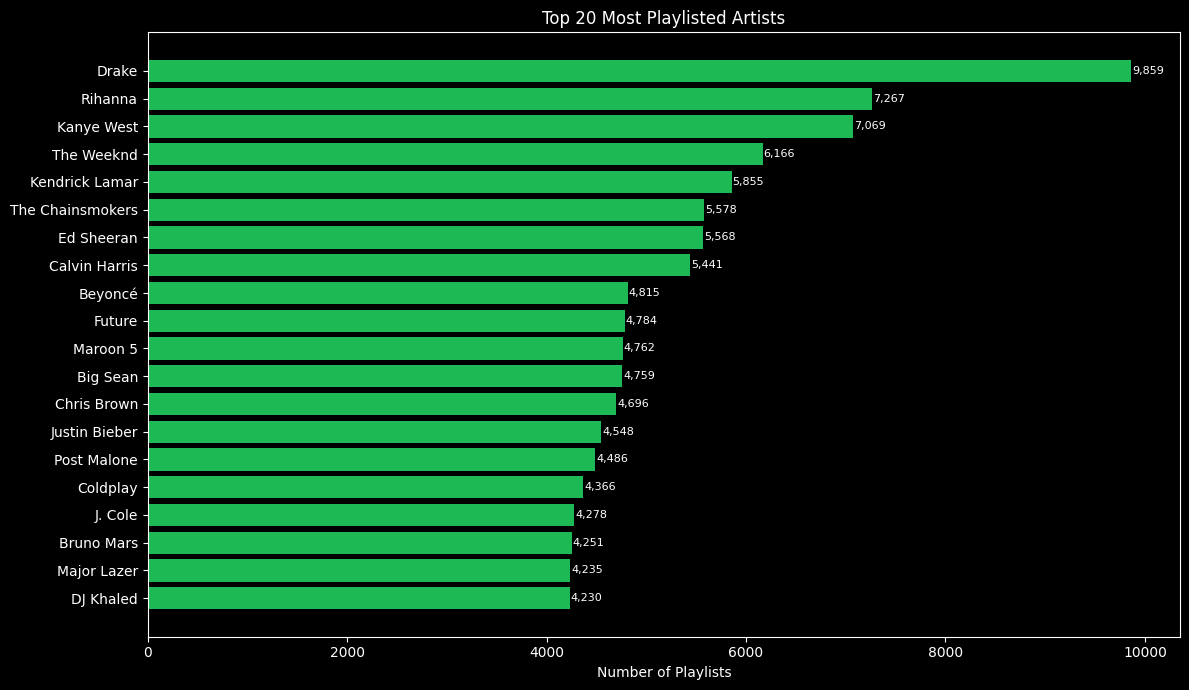

     ARTIST_NAME  PLAYLIST_COUNT  UNIQUE_TRACKS
           Drake            9859            143
         Rihanna            7267            235
      Kanye West            7069            135
      The Weeknd            6166             88
  Kendrick Lamar            5855             96
The Chainsmokers            5578             89
      Ed Sheeran            5568            125
   Calvin Harris            5441            128
         Beyoncé            4815            192
          Future            4784            197


In [19]:
df = query("""
    SELECT 
        a.ARTIST_NAME,
        COUNT(DISTINCT f.PID) AS PLAYLIST_COUNT,
        COUNT(DISTINCT f.TRACK_URI) AS UNIQUE_TRACKS
    FROM SPOTIFY_DW.PUBLIC.FACT_PLAYLIST_TRACKS f
    JOIN SPOTIFY_DW.PUBLIC.DIM_ARTISTS a ON f.ARTIST_URI = a.ARTIST_URI
    GROUP BY a.ARTIST_NAME
    ORDER BY PLAYLIST_COUNT DESC
    LIMIT 20
""")

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(df["ARTIST_NAME"][::-1], df["PLAYLIST_COUNT"][::-1], color="#1DB954")
ax.set_xlabel("Number of Playlists")
ax.set_title("Top 20 Most Playlisted Artists")
for bar, val in zip(bars, df["PLAYLIST_COUNT"][::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("insight2_top_artists.png", dpi=150, bbox_inches="tight")
plt.show()
print(df.head(10).to_string(index=False))

/Users/jaikeerthanap/Library/Python/3.9/lib/python/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/var/folders/sw/0fbg873j55x_xv7ydzyp_l0m0000gn/T/ipykernel_28095/4059469240.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


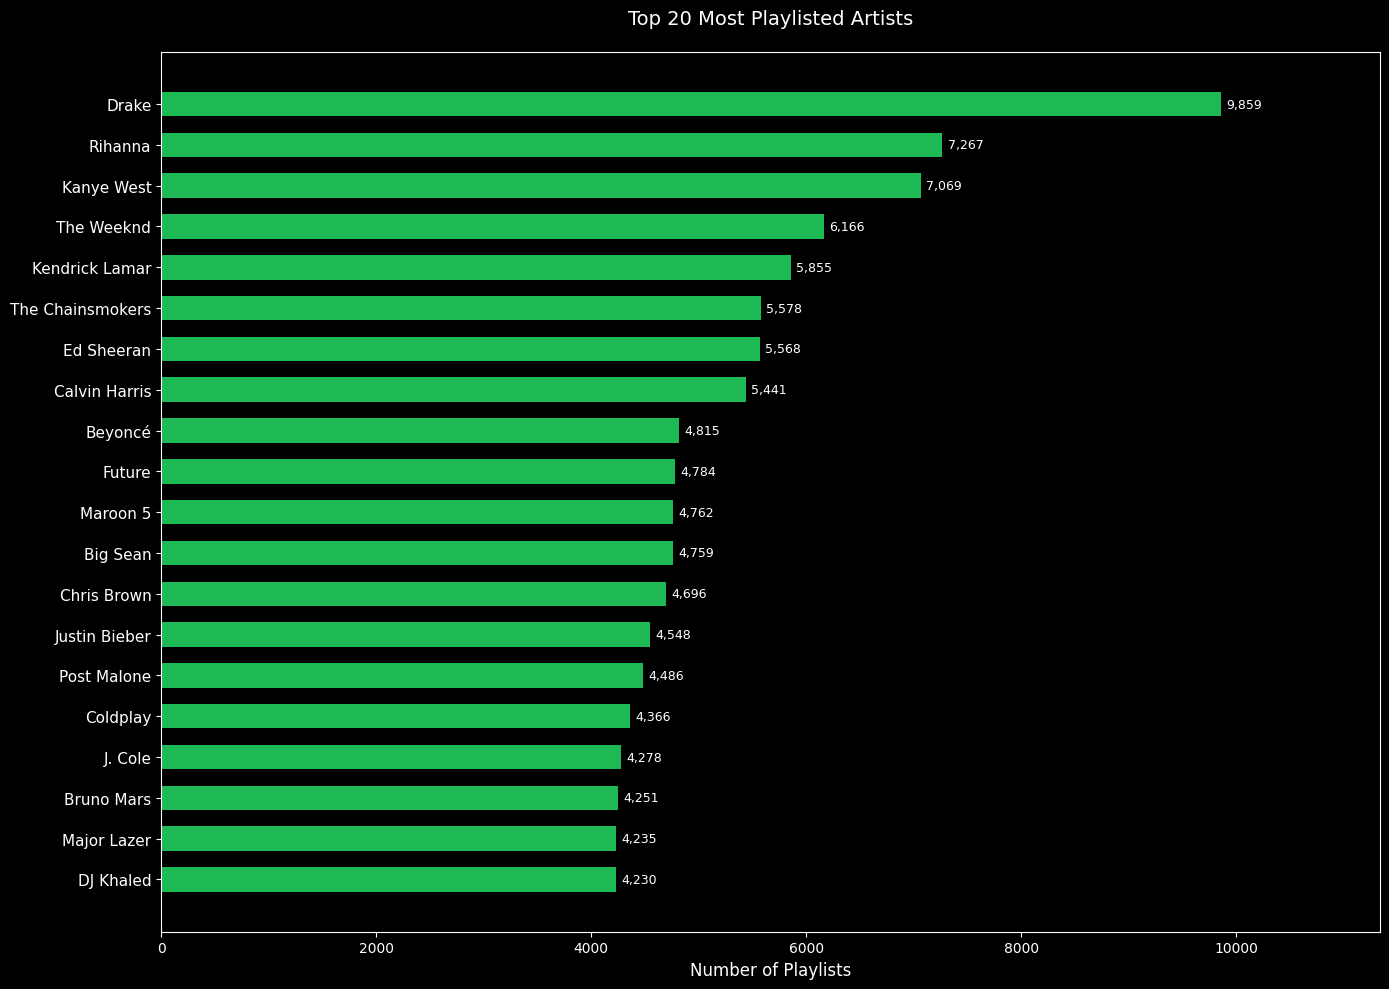

In [22]:
df = query("""
    SELECT 
        a.ARTIST_NAME,
        COUNT(DISTINCT f.PID) AS PLAYLIST_COUNT,
        COUNT(DISTINCT f.TRACK_URI) AS UNIQUE_TRACKS
    FROM SPOTIFY_DW.PUBLIC.FACT_PLAYLIST_TRACKS f
    JOIN SPOTIFY_DW.PUBLIC.DIM_ARTISTS a ON f.ARTIST_URI = a.ARTIST_URI
    GROUP BY a.ARTIST_NAME
    ORDER BY PLAYLIST_COUNT DESC
    LIMIT 20
""")

fig, ax = plt.subplots(figsize=(14, 10))
bars = ax.barh(df["ARTIST_NAME"][::-1], df["PLAYLIST_COUNT"][::-1], color="#1DB954", height=0.6)
ax.set_xlabel("Number of Playlists", fontsize=12)
ax.set_title("Top 20 Most Playlisted Artists", fontsize=14, pad=20)
ax.tick_params(axis='y', labelsize=11)
for bar, val in zip(bars, df["PLAYLIST_COUNT"][::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=9)
ax.set_xlim(0, df["PLAYLIST_COUNT"].max() * 1.15)
plt.tight_layout()
plt.savefig("insight2_top_artists.png", dpi=150, bbox_inches="tight")
plt.show()

/Users/jaikeerthanap/Library/Python/3.9/lib/python/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/var/folders/sw/0fbg873j55x_xv7ydzyp_l0m0000gn/T/ipykernel_28095/4059469240.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


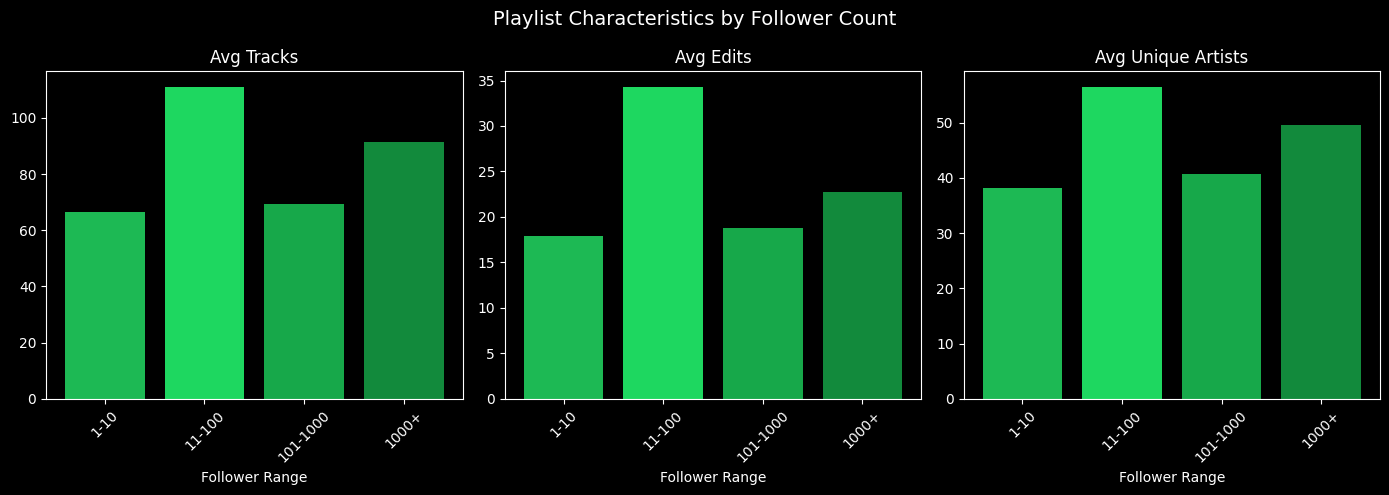

FOLLOWER_BUCKET  PLAYLIST_COUNT  AVG_TRACKS  AVG_EDITS  AVG_ARTISTS
           1-10           49715   66.656945  17.887398    38.144081
         11-100             254  111.019685  34.295276    56.456693
       101-1000              23   69.347826  18.826087    40.739130
          1000+               8   91.250000  22.750000    49.500000


In [21]:
df = query("""
    SELECT
        CASE
            WHEN NUM_FOLLOWERS = 0 THEN 'No followers'
            WHEN NUM_FOLLOWERS BETWEEN 1 AND 10 THEN '1-10'
            WHEN NUM_FOLLOWERS BETWEEN 11 AND 100 THEN '11-100'
            WHEN NUM_FOLLOWERS BETWEEN 101 AND 1000 THEN '101-1000'
            ELSE '1000+'
        END AS FOLLOWER_BUCKET,
        COUNT(*) AS PLAYLIST_COUNT,
        AVG(NUM_TRACKS) AS AVG_TRACKS,
        AVG(NUM_EDITS) AS AVG_EDITS,
        AVG(NUM_ARTISTS) AS AVG_ARTISTS
    FROM SPOTIFY_DW.PUBLIC.DIM_PLAYLISTS
    GROUP BY FOLLOWER_BUCKET
    ORDER BY PLAYLIST_COUNT DESC
""")

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ["AVG_TRACKS", "AVG_EDITS", "AVG_ARTISTS"]
titles = ["Avg Tracks", "Avg Edits", "Avg Unique Artists"]
colors = ["#1DB954", "#1ED760", "#17A84A", "#128A3C", "#0D6B2E"]

for ax, metric, title in zip(axes, metrics, titles):
    ax.bar(df["FOLLOWER_BUCKET"], df[metric], color=colors)
    ax.set_title(title)
    ax.set_xlabel("Follower Range")
    ax.tick_params(axis='x', rotation=45)

plt.suptitle("Playlist Characteristics by Follower Count", fontsize=14)
plt.tight_layout()
plt.savefig("insight3_follower_buckets.png", dpi=150, bbox_inches="tight")
plt.show()
print(df.to_string(index=False))

/Users/jaikeerthanap/Library/Python/3.9/lib/python/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/var/folders/sw/0fbg873j55x_xv7ydzyp_l0m0000gn/T/ipykernel_28095/4059469240.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


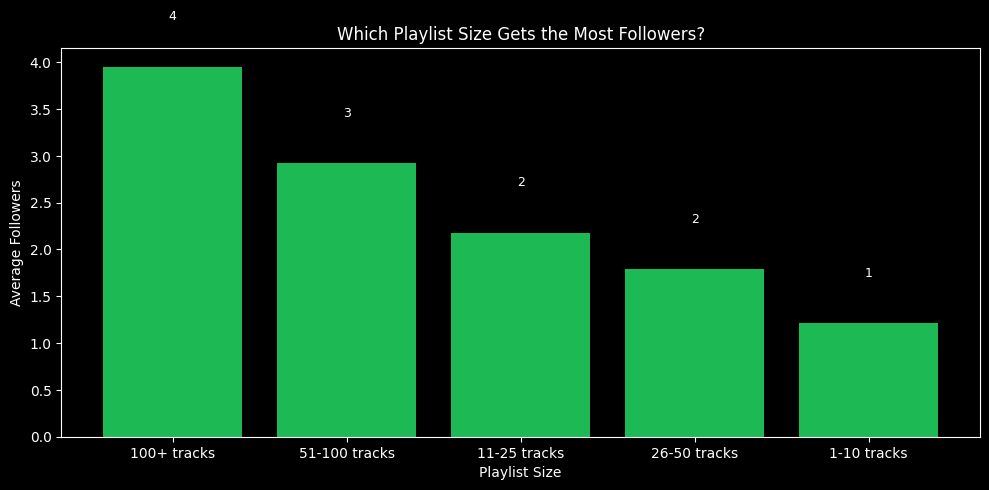

 TRACK_BUCKET  AVG_FOLLOWERS  PLAYLIST_COUNT
  100+ tracks       3.953433           10995
51-100 tracks       2.918713           13643
 11-25 tracks       2.175714            9800
 26-50 tracks       1.790073           13338
  1-10 tracks       1.210881            2224


In [18]:
df = query("""
    SELECT
        CASE
            WHEN NUM_TRACKS BETWEEN 1  AND 10  THEN '1-10 tracks'
            WHEN NUM_TRACKS BETWEEN 11 AND 25  THEN '11-25 tracks'
            WHEN NUM_TRACKS BETWEEN 26 AND 50  THEN '26-50 tracks'
            WHEN NUM_TRACKS BETWEEN 51 AND 100 THEN '51-100 tracks'
            ELSE '100+ tracks'
        END AS TRACK_BUCKET,
        AVG(NUM_FOLLOWERS) AS AVG_FOLLOWERS,
        COUNT(*)           AS PLAYLIST_COUNT
    FROM SPOTIFY_DW.PUBLIC.STG_PLAYLISTS
    WHERE NUM_FOLLOWERS > 0
    GROUP BY TRACK_BUCKET
    ORDER BY AVG_FOLLOWERS DESC
""")

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(df["TRACK_BUCKET"], df["AVG_FOLLOWERS"], color="#1DB954")
ax.set_xlabel("Playlist Size")
ax.set_ylabel("Average Followers")
ax.set_title("Which Playlist Size Gets the Most Followers?")
for bar, val in zip(bars, df["AVG_FOLLOWERS"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.0f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("insight4_sweet_spot.png", dpi=150, bbox_inches="tight")
plt.show()
print(df.to_string(index=False))

/Users/jaikeerthanap/Library/Python/3.9/lib/python/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/var/folders/sw/0fbg873j55x_xv7ydzyp_l0m0000gn/T/ipykernel_28095/4059469240.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)


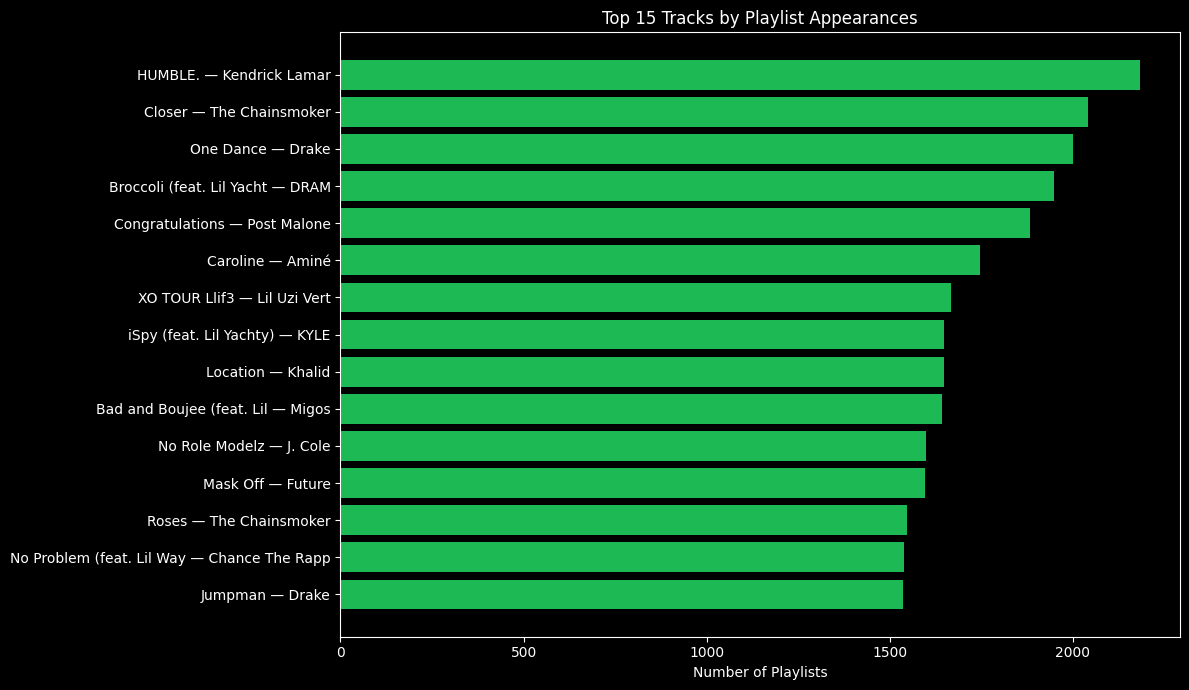

                         TRACK_NAME      ARTIST_NAME  PLAYLIST_COUNT
                            HUMBLE.   Kendrick Lamar            2183
                             Closer The Chainsmokers            2041
                          One Dance            Drake            1999
        Broccoli (feat. Lil Yachty)             DRAM            1949
                    Congratulations      Post Malone            1883
                           Caroline            Aminé            1746
                      XO TOUR Llif3     Lil Uzi Vert            1667
            iSpy (feat. Lil Yachty)             KYLE            1649
                           Location           Khalid            1647
Bad and Boujee (feat. Lil Uzi Vert)            Migos            1643


In [20]:
df = query("""
    SELECT 
        t.TRACK_NAME,
        a.ARTIST_NAME,
        COUNT(DISTINCT f.PID) AS PLAYLIST_COUNT
    FROM SPOTIFY_DW.PUBLIC.FACT_PLAYLIST_TRACKS f
    JOIN SPOTIFY_DW.PUBLIC.DIM_TRACKS t ON f.TRACK_URI = t.TRACK_URI
    JOIN SPOTIFY_DW.PUBLIC.DIM_ARTISTS a ON f.ARTIST_URI = a.ARTIST_URI
    GROUP BY t.TRACK_NAME, a.ARTIST_NAME
    ORDER BY PLAYLIST_COUNT DESC
    LIMIT 15
""")

fig, ax = plt.subplots(figsize=(12, 7))
labels = [f"{r.TRACK_NAME[:25]} — {r.ARTIST_NAME[:15]}" for _, r in df.iterrows()]
bars = ax.barh(labels[::-1], df["PLAYLIST_COUNT"][::-1], color="#1DB954")
ax.set_xlabel("Number of Playlists")
ax.set_title("Top 15 Tracks by Playlist Appearances")
plt.tight_layout()
plt.savefig("insight5_top_tracks.png", dpi=150, bbox_inches="tight")
plt.show()
print(df.head(10).to_string(index=False))

In [23]:
summary = """
I analyzed 50,000 real Spotify playlists from the Million Playlist Dataset
— that's 3.3 million track relationships and 461,000 unique songs. I wanted
to understand what separates playlists that grow followers from ones that
stay personal. Here's what I found.

## 1. More tracks ≠ more followers
I expected longer playlists to attract more listeners but the data
disagrees. The scatter plot is almost flat — a 250-track playlist
is no more likely to blow up than a 20-track one. What you put in
matters more than how much.

## 2. Drake is everywhere
Drake appears in nearly 1 in 5 playlists — 9,859 out of 50,000.
That's not just popularity, that's cultural dominance. The top 20
artists follow a classic power-law distribution where a tiny group
captures a hugely disproportionate share of playlist real estate.

## 3. The 11-100 follower tier is where the real curators live
Playlists with 11-100 followers have 67% more tracks, double the
edits, and 48% more unique artists than low-follower playlists.
These are people actively building something — and the effort shows.

## 4. Longer playlists do get more followers — but it's not linear
100+ track playlists average 3.95 followers vs 1.2 for playlists
under 10 tracks. But the jump happens early — after 50 tracks the
returns diminish. There's a sweet spot around 50-100 tracks where
effort pays off most.

## 5. HUMBLE. by Kendrick Lamar is the most playlisted song
2,183 playlists contain HUMBLE. — more than any other track in the
dataset. Closer by The Chainsmokers and One Dance by Drake follow
closely. These songs became cultural anchors that people reached for
regardless of what kind of playlist they were building.
"""

print(summary)


I analyzed 50,000 real Spotify playlists from the Million Playlist Dataset
— that's 3.3 million track relationships and 461,000 unique songs. I wanted
to understand what separates playlists that grow followers from ones that
stay personal. Here's what I found.

## 1. More tracks ≠ more followers
I expected longer playlists to attract more listeners but the data
disagrees. The scatter plot is almost flat — a 250-track playlist
is no more likely to blow up than a 20-track one. What you put in
matters more than how much.

## 2. Drake is everywhere
Drake appears in nearly 1 in 5 playlists — 9,859 out of 50,000.
That's not just popularity, that's cultural dominance. The top 20
artists follow a classic power-law distribution where a tiny group
captures a hugely disproportionate share of playlist real estate.

## 3. The 11-100 follower tier is where the real curators live
Playlists with 11-100 followers have 67% more tracks, double the
edits, and 48% more unique artists than low-follower pla